In [1]:
from modules.histogram_maker import SafeHistogramMaker, create_histogram_maker_from_file
from modules.add_invariant_mass import add_invariant_mass
from modules.add_jet_control_parameters import add_jet_control_parameters
import dask.dataframe as dd
import numpy as np

In [2]:
# Caricamento dati

file_path = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
#file_path = "data/WJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS45000001.parquet"
parameters = [
    # Jets
    "FullReco_JetAK4_PT",
    "FullReco_JetAK4_Eta",
    "FullReco_JetAK4_Phi",
    "FullReco_JetAK4_Mass",
    "FullReco_JetAK4_Charge",
    "FullReco_JetAK4_Constituents",

    #Contituents
    "FullReco_PFCand_PT",
    "FullReco_PFCand_Eta",
    "FullReco_PFCand_Phi",
    "FullReco_PFCand_Charge",
    "FullReco_PFCand_Mass",
    "FullReco_PFCand_fUniqueID",
    "FullReco_PFCand_PID"
]

ddf = dd.read_parquet(file_path, parameters)

# Aggiungi massa invariante
ddf_im = add_invariant_mass(ddf, use_leading=True, n_leading=2)

In [3]:
print("numero di eventi =", len(ddf["FullReco_JetAK4_PT"]))

n=5

# per accedere ai primi n eventi
pt_first = ddf['FullReco_JetAK4_PT'].head(n)
print("######## First n pts: #########\n", pt_first)

# per accedere all'evento n esimo
pt_n = ddf['FullReco_JetAK4_PT'].loc[n].compute()
print("\n######### pt in index n: #########\n", pt_n)

# altri comandi
print("\n######### usando [0] ottengo i dati associati al idx 0: #########\n", pt_first[0])
print("\n######### usando .iloc[0] ottengo i dati associati al idx 0: #########\n", pt_first.iloc[0])
print("\n######### usando [0][0] ottengo l'elemento 0 nel idx 0: #########\n", pt_first[0][0])

numero di eventi = 9972
######## First n pts: #########
 0                                       [27.83, 15.55]
1                           [55.6, 41.88, 32.4, 30.17]
2                                 [71.1, 36.72, 18.34]
3     [47.88, 41.34, 32.62, 24.06, 20.23, 19.8, 18.33]
4    [28.1, 25.89, 21.17, 19.61, 18.62, 18.5, 17.73...
Name: FullReco_JetAK4_PT, dtype: object

######### pt in index n: #########
 5    [43.47, 23.44]
Name: FullReco_JetAK4_PT, dtype: object

######### usando [0] ottengo i dati associati al idx 0: #########
 [27.83 15.55]

######### usando .iloc[0] ottengo i dati associati al idx 0: #########
 [27.83 15.55]

######### usando [0][0] ottengo l'elemento 0 nel idx 0: #########
 27.83


Appiattimento colonna: FullReco_JetAK4_PT
  Trovati 60,989 valori validi

--- FullReco_JetAK4_PT ---
  Elementi validi: 60,907
  Range dati: [15.008, 405.500]


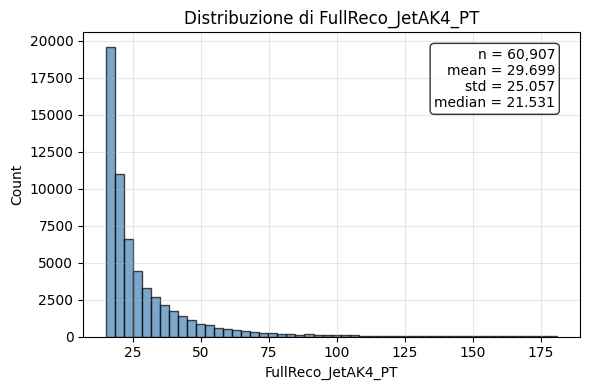

Appiattimento colonna: FullReco_JetAK4_Eta
  Trovati 60,989 valori validi

--- FullReco_JetAK4_Eta ---
  Elementi validi: 60,870
  Range dati: [-4.852, 4.898]


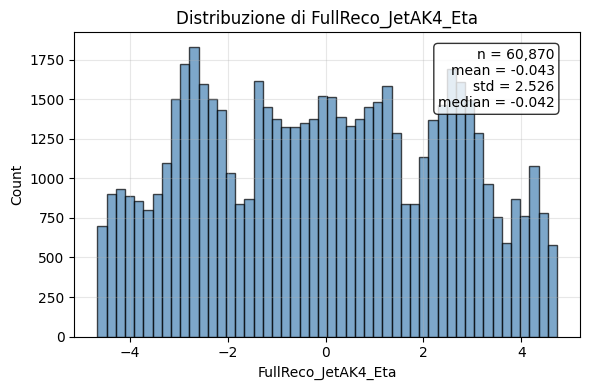

Appiattimento colonna: FullReco_JetAK4_Phi
  Trovati 60,989 valori validi

--- FullReco_JetAK4_Phi ---
  Elementi validi: 60,876
  Range dati: [-3.135, 3.135]


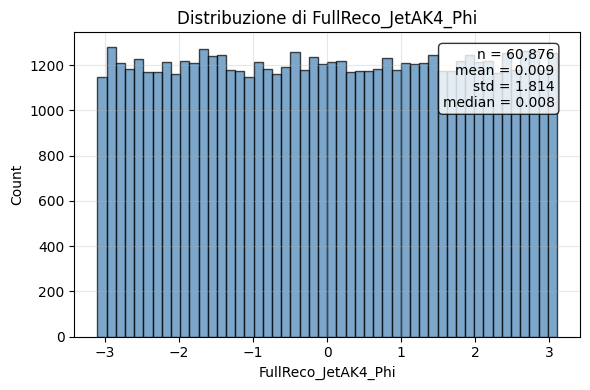

Appiattimento colonna: FullReco_JetAK4_Charge
  Trovati 60,989 valori validi

--- FullReco_JetAK4_Charge ---
  Elementi validi: 60,989
  Range dati: [-1.000, 1.000]


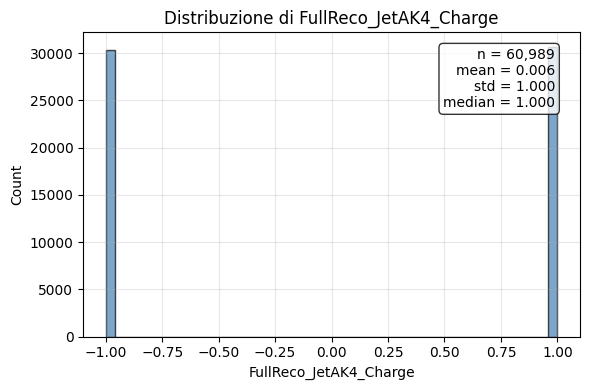

Appiattimento colonna: FullReco_JetAK4_Mass
  Trovati 60,989 valori validi

--- FullReco_JetAK4_Mass ---
  Elementi validi: 60,868
  Range dati: [-7.793, 39.906]


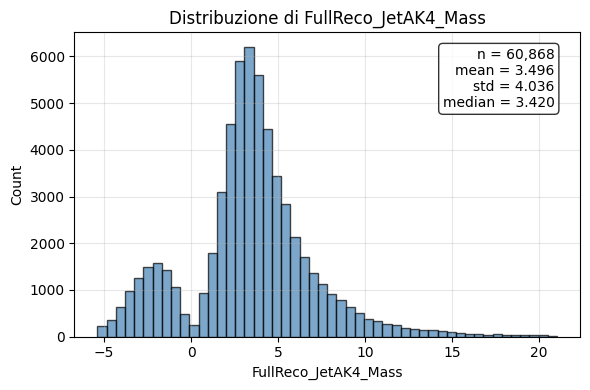

Appiattimento colonna: FullReco_PFCand_PT
  Trovati 40,114,507 valori validi

--- FullReco_PFCand_PT ---
  Elementi validi: 40,034,403
  Range dati: [0.061, 10.375]


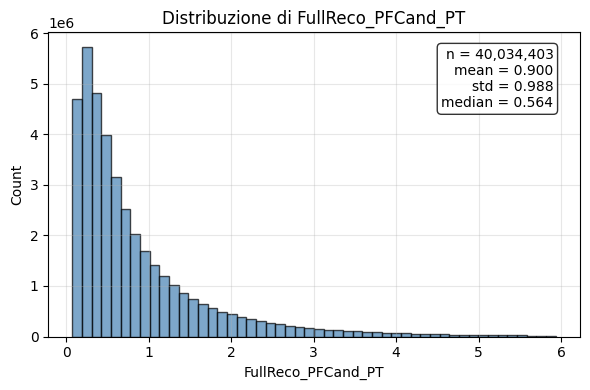

Appiattimento colonna: FullReco_PFCand_Eta
  Trovati 40,114,507 valori validi

--- FullReco_PFCand_Eta ---
  Elementi validi: 40,050,125
  Range dati: [-4.984, 4.984]


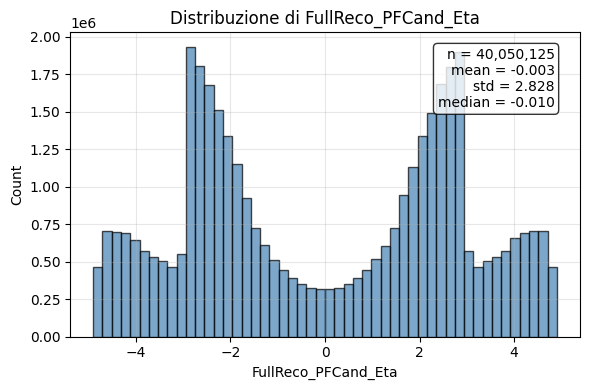

Appiattimento colonna: FullReco_PFCand_Phi
  Trovati 40,114,507 valori validi

--- FullReco_PFCand_Phi ---
  Elementi validi: 40,039,377
  Range dati: [-3.135, 3.135]


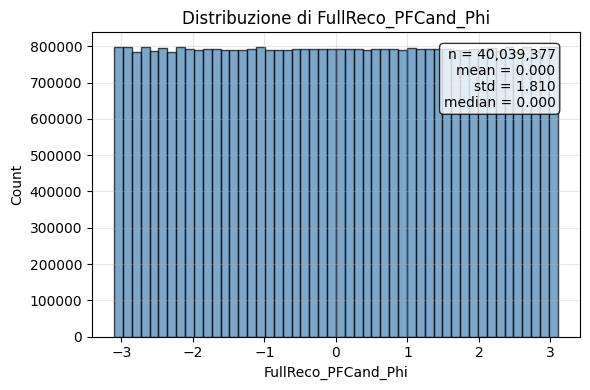

Appiattimento colonna: FullReco_PFCand_Charge
  Trovati 40,114,507 valori validi

--- FullReco_PFCand_Charge ---
  Elementi validi: 40,114,507
  Range dati: [-1.000, 1.000]


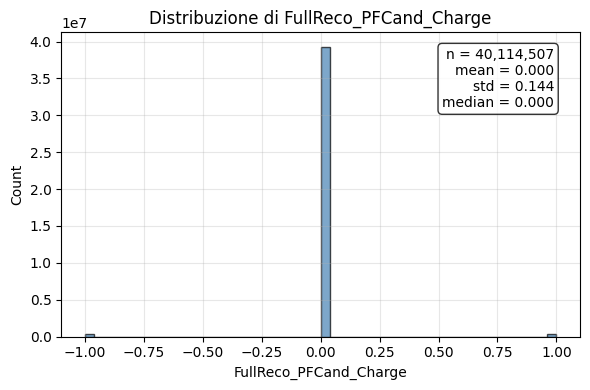

Appiattimento colonna: FullReco_PFCand_Mass
  Trovati 40,114,507 valori validi

--- FullReco_PFCand_Mass ---
  Elementi validi: 40,071,817
  Range dati: [-0.000, 0.938]


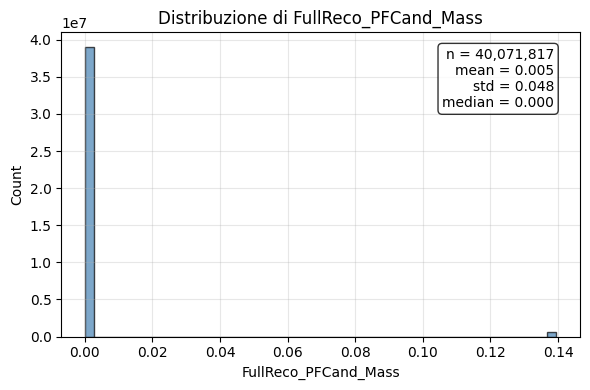


--- invariant_mass ---
  Elementi validi: 3,798
  Range dati: [15.539, 244.625]


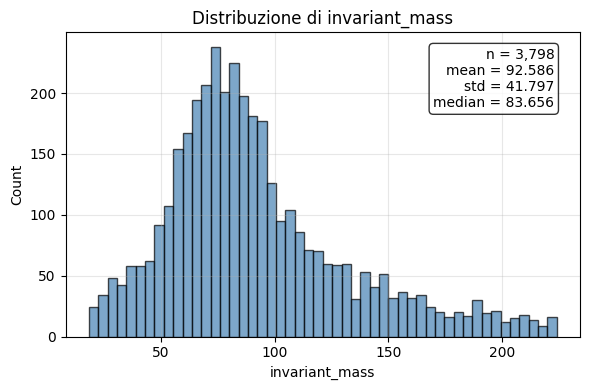

In [4]:
# Crea l'istogramma
maker = SafeHistogramMaker(ddf_im, verbose=True)
plot_columns = ["FullReco_JetAK4_PT", "FullReco_JetAK4_Eta", "FullReco_JetAK4_Phi", "FullReco_JetAK4_Charge", "FullReco_JetAK4_Mass",
                "FullReco_PFCand_PT",    "FullReco_PFCand_Eta",    "FullReco_PFCand_Phi",    "FullReco_PFCand_Charge",    "FullReco_PFCand_Mass",
                "invariant_mass"]
maker.make_histograms_for_columns(plot_columns, bins=50)


--- FullReco_PFCand_Mass ---
  Elementi validi: 40,071,817
  Range dati: [-0.000, 0.938]


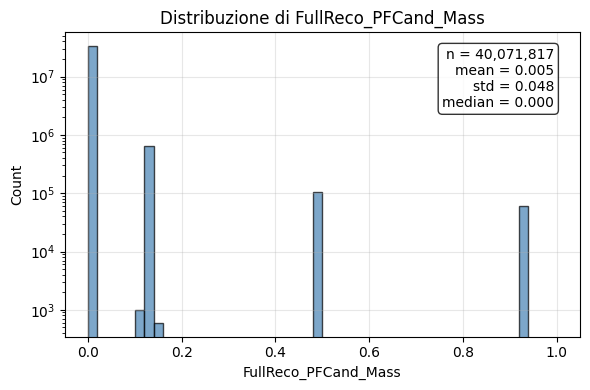

In [8]:
maker.make_histograms_for_columns(['FullReco_PFCand_Mass'], bins=50, range_dict={'FullReco_PFCand_Mass': (0, 1)}, log_scale=True)


--- charge_control ---
  Elementi validi: 5,556
  Range dati: [-6.000, 5.000]


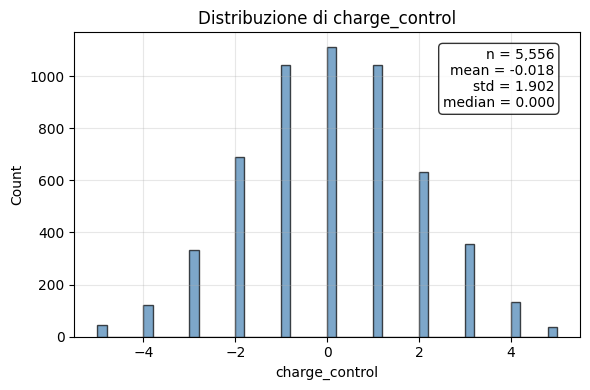


--- pt_control ---
  Elementi validi: 5,460
  Range dati: [-0.853, 0.523]


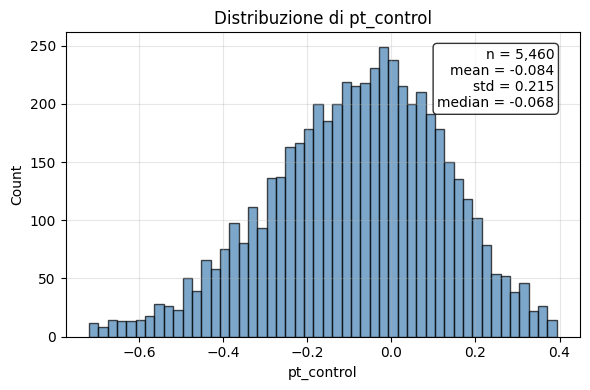


--- mass_control ---
  Elementi validi: 3,483
  Range dati: [-0.601, 11.727]


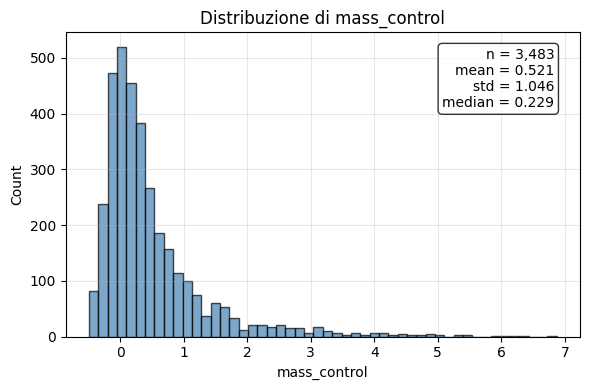


--- n_constituents ---
  Elementi validi: 5,555
  Range dati: [4.000, 53.000]


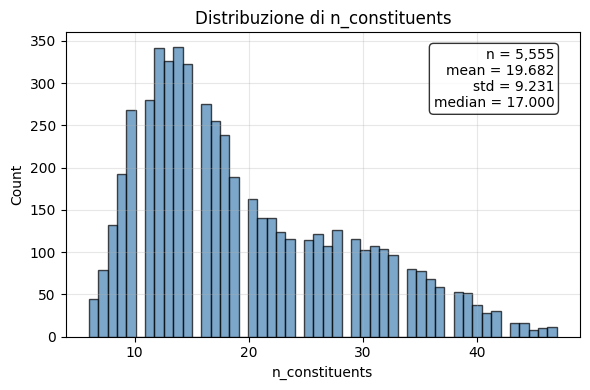


--- distance ---
  Elementi validi: 5,552
  Range dati: [0.000, 1.747]


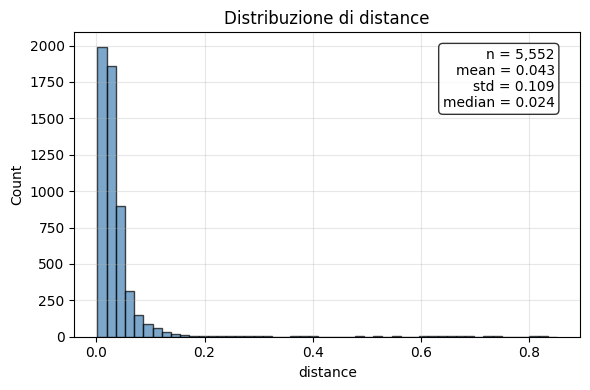

In [3]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)

# Crea l'istogramma per parametri di controllo
maker_control = SafeHistogramMaker(ddf_control, verbose=True)

maker_control.make_all_histograms(bins=50)


--- charge_control ---
  Elementi validi: 6,170
  Range dati: [-6.000, 5.000]


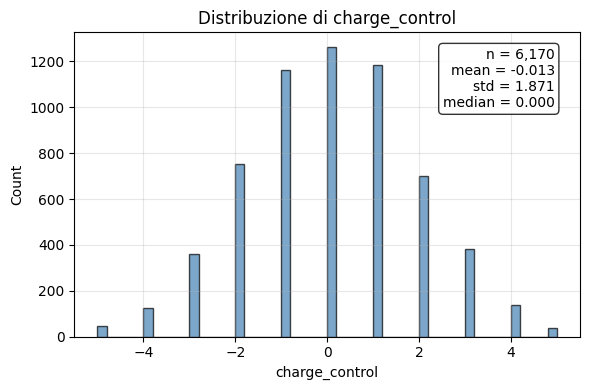


--- pt_control ---
  Elementi validi: 6,068
  Range dati: [-0.939, 0.523]


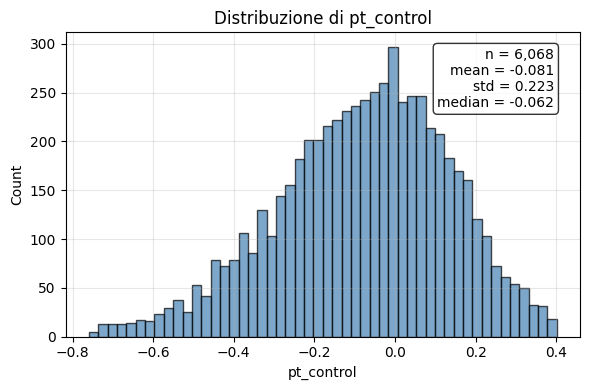


--- mass_control ---
  Elementi validi: 3,895
  Range dati: [-20.656, 11.727]


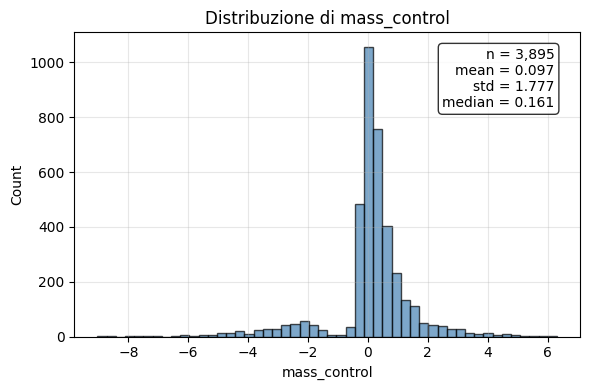


--- n_constituents ---
  Elementi validi: 6,170
  Range dati: [2.000, 53.000]


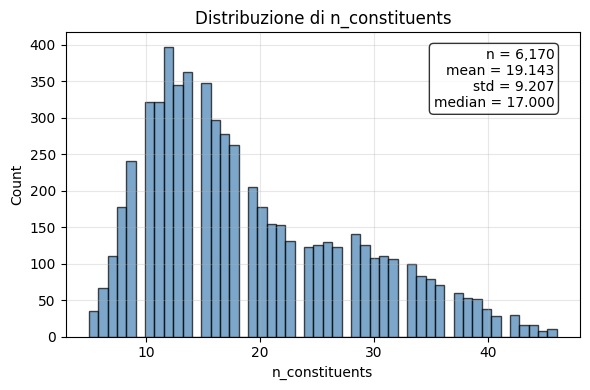


--- distance ---
  Elementi validi: 6,165
  Range dati: [0.001, 1.743]


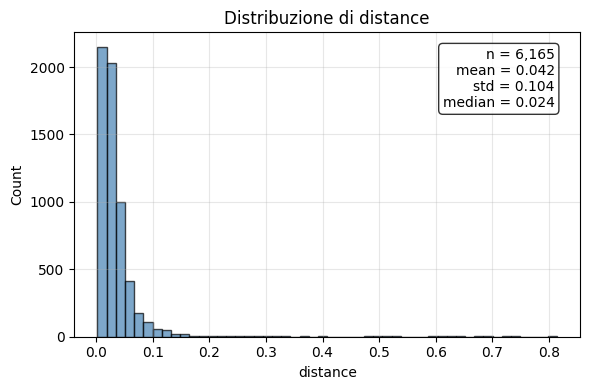

In [4]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = False)

# Crea l'istogramma per parametri di controllo
maker_control = SafeHistogramMaker(ddf_control, verbose=True)

maker_control.make_all_histograms(bins=50)


--- n_constituents ---
  Elementi validi: 5,555
  Range dati: [4.000, 53.000]


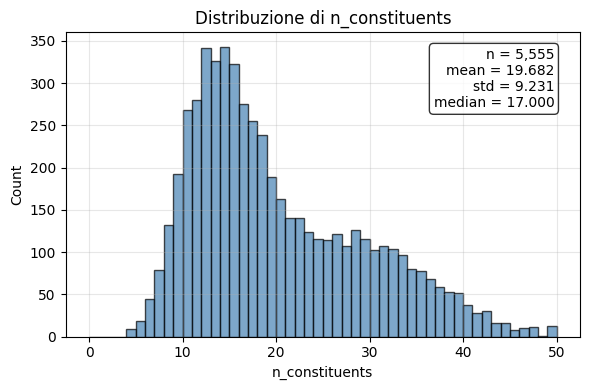


--- distance ---
  Elementi validi: 5,552
  Range dati: [0.000, 1.747]


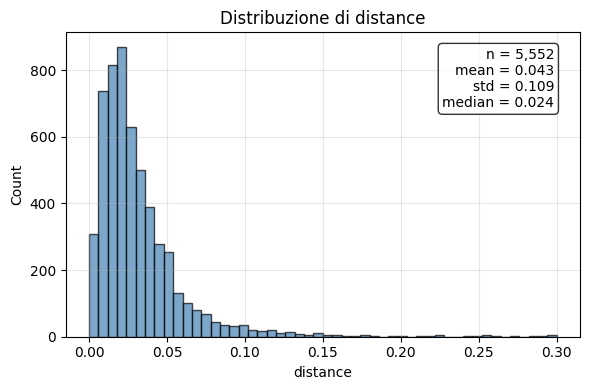

In [6]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)
maker_control = SafeHistogramMaker(ddf_control, verbose=True)
maker_control.make_histograms_for_columns(['n_constituents', 'distance'], bins=50, range_dict={'n_constituents': (0, 50), 'distance': (0, 0.3)})


--- charge_control ---
  Elementi validi: 5,909
  Range dati: [-6.000, 5.000]


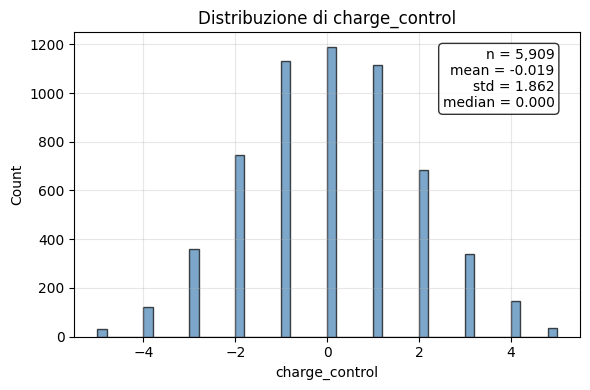


--- pt_control ---
  Elementi validi: 5,815
  Range dati: [-0.869, 0.253]


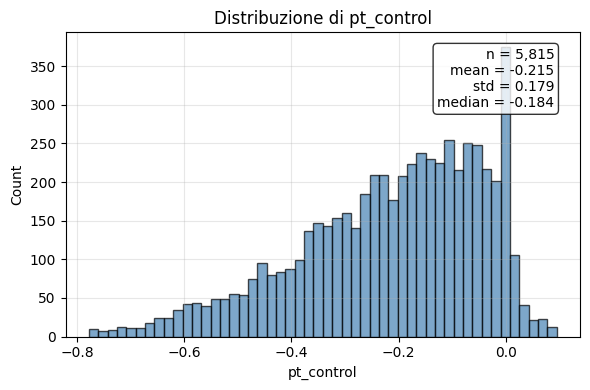


--- mass_control ---
  Elementi validi: 4,012
  Range dati: [-0.755, 3.629]


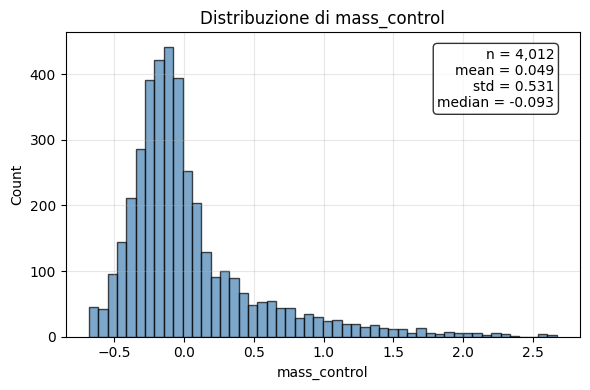


--- n_constituents ---
  Elementi validi: 5,911
  Range dati: [1.000, 38.000]


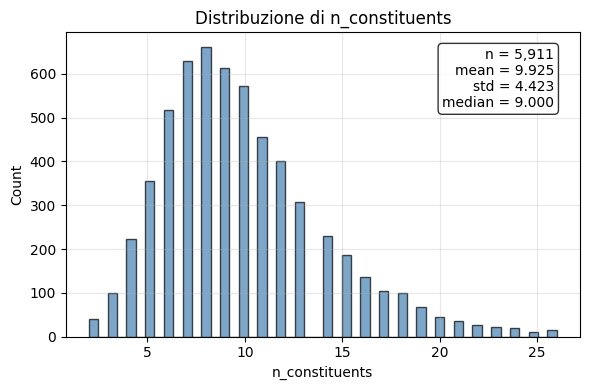


--- distance ---
  Elementi validi: 5,911
  Range dati: [0.000, 1.741]


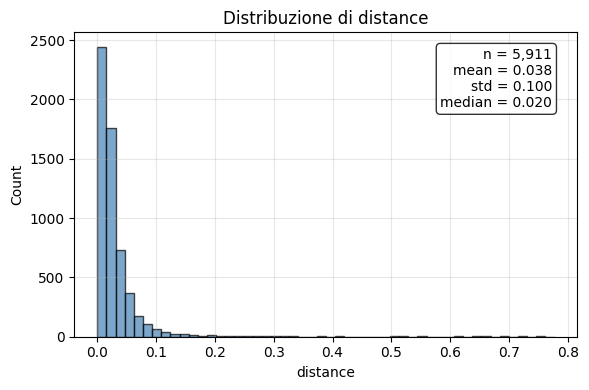

In [17]:
from modules.add_jet_control_parameters_puppi import add_jet_control_parameters_puppi

parameters_puppi = [
    # Jets
    "FullReco_JetPuppiAK4_PT",
    "FullReco_JetPuppiAK4_Eta",
    "FullReco_JetPuppiAK4_Phi",
    "FullReco_JetPuppiAK4_Mass",
    "FullReco_JetPuppiAK4_Charge",
    "FullReco_JetPuppiAK4_Constituents",

    #Contituents
    "FullReco_PUPPIPart_PT",
    "FullReco_PUPPIPart_Eta",
    "FullReco_PUPPIPart_Phi",
    "FullReco_PUPPIPart_Charge",
    "FullReco_PUPPIPart_Mass",
    "FullReco_PUPPIPart_fUniqueID",
    "FullReco_PUPPIPart_PID"
]

ddf_puppi = dd.read_parquet(file_path, parameters_puppi)

ddf_control_puppi = add_jet_control_parameters_puppi(ddf_puppi, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)

# Crea l'istogramma per parametri di controllo
maker_control_puppi = SafeHistogramMaker(ddf_control_puppi, verbose=True)

maker_control_puppi.make_all_histograms(bins=50)


--- n_constituents ---
  Elementi validi: 5,911
  Range dati: [1.000, 38.000]


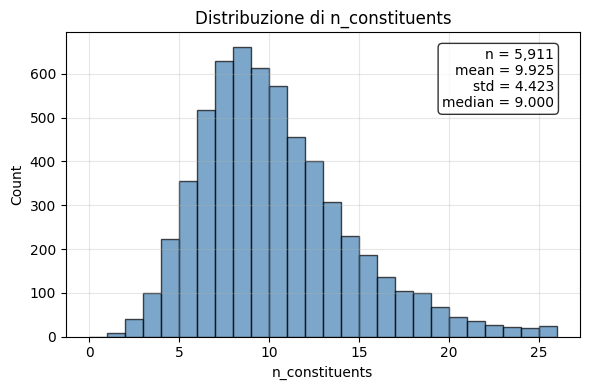


--- distance ---
  Elementi validi: 5,911
  Range dati: [0.000, 1.741]


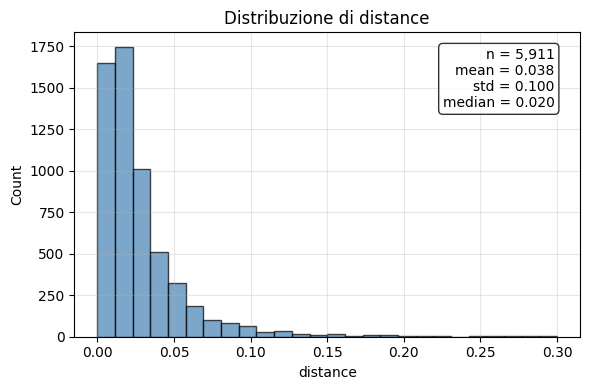

In [18]:
maker_control_puppi.make_histograms_for_columns(['n_constituents', 'distance'], bins=26, range_dict={'n_constituents': (0, 26), 'distance': (0, 0.3)})

In [12]:
import dask.dataframe as dd

# Leggi il Dask DataFrame
ddf_test = dd.read_parquet(file_path)

# I nomi delle colonne sono accessibili allo stesso modo
nomi_colonne = ddf_test.columns.tolist()
print(np.vstack(nomi_colonne))

[['FullReco_PFCand_PT']
 ['FullReco_PFCand_Eta']
 ['FullReco_PFCand_Phi']
 ['FullReco_PFCand_PID']
 ['FullReco_PFCand_Charge']
 ['FullReco_PFCand_Mass']
 ['FullReco_PFCand_D0']
 ['FullReco_PFCand_DZ']
 ['FullReco_PFCand_ErrorD0']
 ['FullReco_PFCand_ErrorDZ']
 ['FullReco_PFCand_fUniqueID']
 ['FullReco_PFCand_PuppiW']
 ['FullReco_PUPPIPart_PT']
 ['FullReco_PUPPIPart_Eta']
 ['FullReco_PUPPIPart_Phi']
 ['FullReco_PUPPIPart_Charge']
 ['FullReco_PUPPIPart_Mass']
 ['FullReco_PUPPIPart_PID']
 ['FullReco_PUPPIPart_D0']
 ['FullReco_PUPPIPart_DZ']
 ['FullReco_PUPPIPart_ErrorD0']
 ['FullReco_PUPPIPart_ErrorDZ']
 ['FullReco_PUPPIPart_fUniqueID']
 ['FullReco_PUPPIPart_PuppiW']
 ['FullReco_Electron_PT']
 ['FullReco_Electron_Eta']
 ['FullReco_Electron_Phi']
 ['FullReco_Electron_EhadOverEem']
 ['FullReco_Electron_IsolationVarRhoCorr']
 ['FullReco_MuonTight_PT']
 ['FullReco_MuonTight_Eta']
 ['FullReco_MuonTight_Phi']
 ['FullReco_MuonTight_IsolationVarRhoCorr']
 ['FullReco_PhotonTight_PT']
 ['FullReco_Ph

In [15]:
n=30
gen_jet_pt = ddf_test['FullReco_GenJetAK4_PT'].head(n)
gen_jet_eta = ddf_test['FullReco_GenJetAK4_Eta'].head(n)
gen_jet_phi = ddf_test['FullReco_GenJetAK4_Phi'].head(n)

jet_pt = ddf_test['FullReco_JetAK4_PT'].head(n)
jet_eta = ddf_test['FullReco_JetAK4_Eta'].head(n)
jet_phi = ddf_test['FullReco_JetAK4_Phi'].head(n)

print("#" * 50)
print("\t" * 2 , " gen jet pt")
print("#" * 50)
print(gen_jet_pt)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet pt")
print("#" * 50)
print(jet_pt)


print("#" * 50)
print("\t" * 2 , " gen jet eta")
print("#" * 50)
print(gen_jet_eta)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet eta")
print("#" * 50)
print(jet_eta)


print("#" * 50)
print("\t" * 2 , " gen jet phi")
print("#" * 50)
print(gen_jet_phi)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet phi")
print("#" * 50)
print(jet_phi)

##################################################
		  gen jet pt
##################################################
0                                        [38.78, 34.2]
1                                [35.22, 29.11, 27.62]
2                                  [64.5, 53.3, 29.52]
3                                         [46.1, 42.5]
4                                                   []
5                                               [31.3]
6                 [115.56, 77.25, 61.44, 41.66, 17.61]
7                     [59.5, 57.56, 25.47, 22.3, 20.1]
8                                  [43.6, 33.2, 33.16]
9             [159.9, 155.1, 84.2, 38.25, 23.4, 18.34]
10                        [58.44, 43.8, 26.33, 15.555]
11                 [50.16, 36.16, 34.06, 30.45, 17.75]
12                          [35.16, 26.0, 16.3, 15.73]
13                                             [23.28]
14                                [64.75, 35.9, 35.22]
15                        [119.1, 94.06, 33.06, 15.66]
16 